In [3]:
!pip install deeplay

In [4]:
import zipfile
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import time

from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn

from torchvision import transforms as trans
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.transforms import Compose, Normalize, Resize, ToTensor, RandomHorizontalFlip, RandomRotation, GaussianBlur

import deeplay as dl
from deeplay.blocks.sequential import SequentialBlock
from deeplay.components import ConvolutionalEncoder2d
from deeplay.external.layer import Layer
from deeplay.initializers.normal import Normal
from deeplay.blocks.conv.conv2d import Conv2dBlock
from deeplay.components import ConvolutionalDecoder2d
from deeplay.external.layer import Layer
from deeplay.initializers.normal import Normal

In [5]:
!kaggle datasets download -d ikarus777/best-artworks-of-all-time

with zipfile.ZipFile("best-artworks-of-all-time.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

Dataset URL: https://www.kaggle.com/datasets/ikarus777/best-artworks-of-all-time
License(s): CC-BY-NC-SA-4.0
100% 2.29G/2.29G [00:28<00:00, 85.1MB/s]



In [6]:
#Det enda som är ändrat här är att det står [0.5, 0.5, 0.5] istället för [0.5]
transform = Compose([
    Resize((64, 64)), GaussianBlur(kernel_size = 5, sigma = (0.1, 2.0)),
    ToTensor(),
    Normalize(mean=[0.5, 0.5, 0.5],  std=[0.5, 0.5, 0.5])])


# 2. Ladda hela datasetet med ImageFolder
# Denna kollar i "base_path" och mappar varje undermapp till ett index (label)
base_path = "dataset/images/images"
full_dataset = datasets.ImageFolder(root=base_path, transform=transform)
selected_artists = ['Amedeo_Modigliani', 'Piet_Mondrian','Vincent_van_Gogh', 'Edgar_Degas']

# 2. Hitta deras ursprungliga index (t.ex. 11 och 49)
target_indices = [full_dataset.class_to_idx[artist] for artist in selected_artists]

# 3. Skapa en mappning (Dictionary) för att styra om dem
# Nu blir 11 -> 0 och 49 -> 1
label_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(target_indices)}

# 4. Uppdatera ALLA bilders labels i original-datasetet
# full_dataset.samples är en lista med tupler: (sökväg, label)
new_samples = []
indices = []

for i, (path, old_label) in enumerate(full_dataset.samples):
    if old_label in target_indices:
        # Ändra labeln till 0 eller 1 baserat på vår mappning
        new_label = label_mapping[old_label]
        new_samples.append((path, new_label))
        indices.append(i)

# 5. "Injicera" de nya labelsen i dataset-objektet
full_dataset.samples = new_samples
trainset = Subset(full_dataset, range(len(new_samples)))




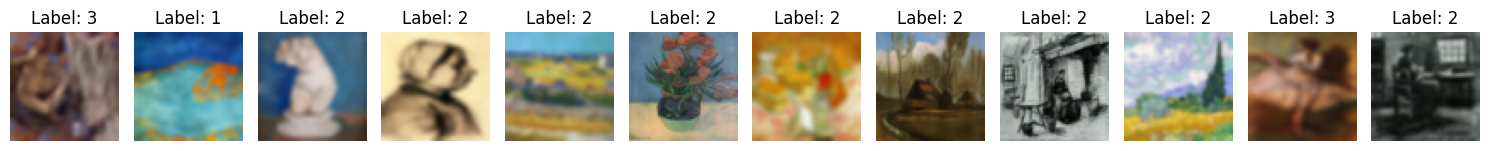

In [7]:


fig, axs = plt.subplots(1, 12, figsize=(15, 3))

for ax in axs.ravel():

    idx = torch.randint(0, len(trainset), (1,)).item()
    img, label = trainset[idx]


    img = img * 0.5 + 0.5


    img_display = img.permute(1, 2, 0).numpy()


    img_display = np.clip(img_display, 0, 1)

    ax.imshow(img_display)
    ax.set_title(f"Label: {label}", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
def get_device():
    """Select device where to perform the computations."""
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Selected device: {device}")

Selected device: cuda:0


In [9]:
nr_of_artists = len(selected_artists)


epochs = 1000
latent_dim = 100
feature_dim = 128
embedding_dim=64
batch_size=64
lr_gen = 0.0002
lr_disc = 0.0001
size_latent_vector = 20
b = (0.5, 0.999)


In [10]:
class DCGANGeneratorCostum(ConvolutionalDecoder2d):

    latent_dim: int
    output_channels: int
    class_conditioned_model: bool
    embedding_dim: int
    num_classes: int

    def __init__(
        self,
        latent_dim: int = 100,
        features_dim: int = 64,
        out_channels: int = 1,
        class_conditioned_model: bool = False,
        embedding_dim: int = 100,
        num_classes: int = 10,
        output_channels=None,
    ):
        if output_channels is not None:
            out_channels = output_channels

        self.latent_dim = latent_dim
        self.output_channels = out_channels
        self.class_conditioned_model = class_conditioned_model
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes

        in_channels = latent_dim
        if class_conditioned_model:
            in_channels += embedding_dim

        super().__init__(
            in_channels=in_channels,
            hidden_channels=[
                features_dim * 16,
                features_dim * 8,
                features_dim * 4,
                features_dim * 2,
            ],
            out_channels=out_channels,
            out_activation=Layer(nn.Tanh),
        )

        if class_conditioned_model:
            self.label_embedding = Layer(nn.Embedding, num_classes, embedding_dim)
        else:
            self.label_embedding = Layer(nn.Identity)

        self.style("dcgan_generator")

    def forward(self, x, y=None):
        if self.class_conditioned_model:
            if y is None:
                raise ValueError(
                    "Class label y must be provided for class-conditional generator"
                )

            y = self.label_embedding(y)
            y = y.view(-1, self.embedding_dim, 1, 1)
            x = torch.cat([x, y], dim=1)

        for block in self.blocks:
            x = block(x)

        return x

In [11]:
class DCGANDiscriminatorCostum(ConvolutionalEncoder2d):

    input_channels: int
    class_conditioned_model: bool
    embedding_dim: int
    num_classes: int

    def __init__(
        self,
        in_channels: int = 1,
        features_dim: int = 64,
        class_conditioned_model: bool = False,
        embedding_dim: int = 100,
        num_classes: int = 10,
        input_channels=None,
    ):
        if input_channels is not None:
            in_channels = input_channels
        if class_conditioned_model:
            in_channels += 1

        self.in_channels = in_channels
        self.features_dim = features_dim
        self.class_conditioned_model = class_conditioned_model
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes

        super().__init__(
            in_channels=in_channels,
            hidden_channels=[
                features_dim,
                features_dim * 2,
                features_dim * 4,
                features_dim * 8,
            ],
            out_channels=1,
            out_activation=Layer(nn.Sigmoid),
        )
        self.features_dim = features_dim
        self.class_conditioned_model = class_conditioned_model

        if class_conditioned_model:


            self.label_embedding = SequentialBlock(
                embedding=Layer(nn.Embedding, num_classes, embedding_dim),
                layer=Layer(nn.Linear, embedding_dim, 64 * 64),
                activation=Layer(nn.LeakyReLU, 0.2),
            )
        else:
            self.label_embedding = Layer(nn.Identity)

        self.style("dcgan_discriminator")

    def forward(self, x, y=None):
        expected_shape = (x.shape[0], self.in_channels, 64, 64)
        if x.shape[-2:] != expected_shape[-2:]:
            raise ValueError(
                f"Input shape is {x.shape}, expected {expected_shape}. DCGAN discriminator expects 64x64 images. "
            )

        if self.class_conditioned_model:
            if y is None:
                raise ValueError(
                    "Class label y must be provided for class-conditional discriminator"
                )

            y = self.label_embedding(y)
            y = y.view(-1, 1, 64, 64)
            x = torch.cat([x, y], dim=1)

        for block in self.blocks:
            x = block(x)

        return x

In [12]:

gen = DCGANGeneratorCostum(
    latent_dim=latent_dim, features_dim=feature_dim, output_channels=3,
    class_conditioned_model=True, embedding_dim=embedding_dim, num_classes=nr_of_artists,
).build().to(device)

disc = DCGANDiscriminatorCostum(
    input_channels=3, features_dim=feature_dim,  class_conditioned_model=True,
    embedding_dim=embedding_dim, num_classes=nr_of_artists,
).build().to(device)

loader = dl.DataLoader(trainset, batch_size=batch_size, shuffle=True, drop_last = True)
loss = torch.nn.BCELoss()

optim_gen = torch.optim.Adam(gen.parameters(), lr=lr_gen, betas=b)
optim_disc = torch.optim.Adam(disc.parameters(), lr=lr_disc, betas=b)


Epoch 1/1000
----------
Batch 1/29: Generator Loss: 1.0192, Discriminator Loss: 0.6887
----------
Epoch 1/1000: Generator Loss: 1.7152, Discriminator Loss: 0.4546, Time taken: 0:00:40.069765


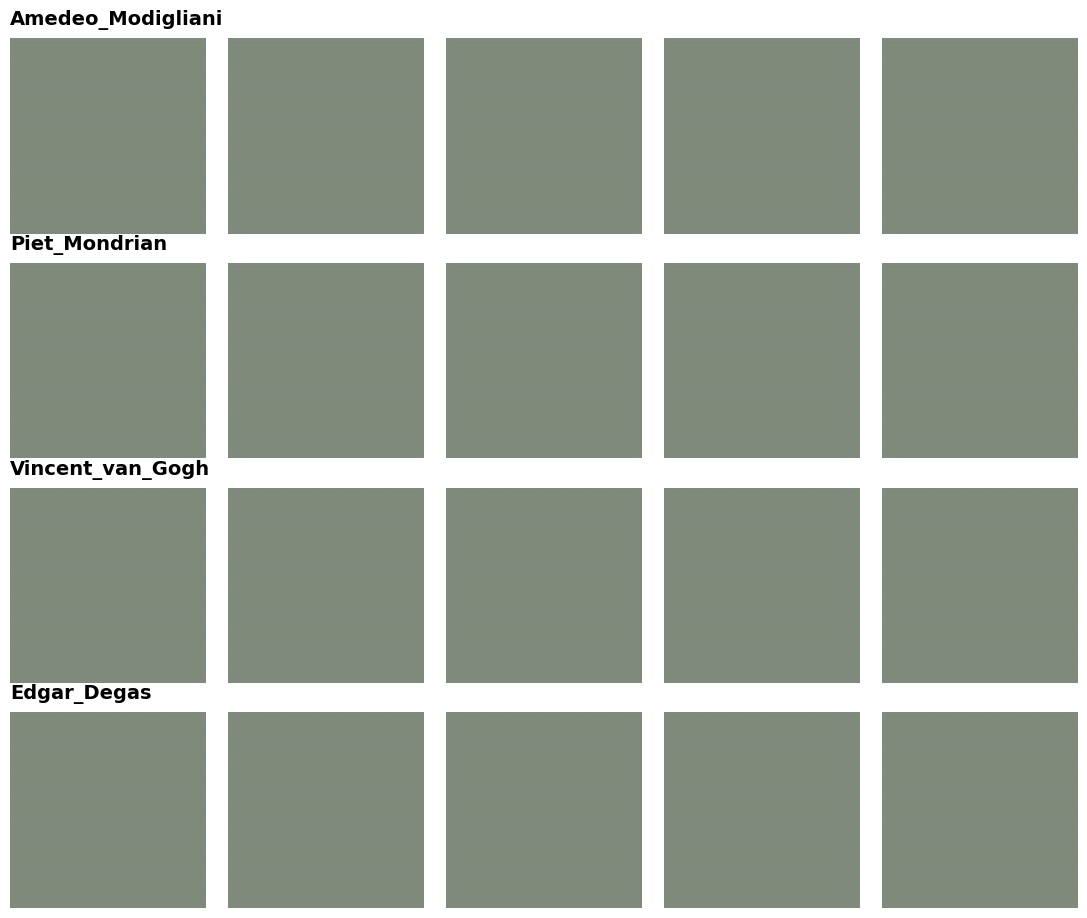


Epoch 2/1000
----------
Batch 1/29: Generator Loss: 2.1304, Discriminator Loss: 0.3406
----------
Epoch 2/1000: Generator Loss: 2.0572, Discriminator Loss: 0.3301, Time taken: 0:00:38.711634

Epoch 3/1000
----------
Batch 1/29: Generator Loss: 2.3559, Discriminator Loss: 0.2420
----------
Epoch 3/1000: Generator Loss: 1.7995, Discriminator Loss: 0.4523, Time taken: 0:00:38.446413

Epoch 4/1000
----------
Batch 1/29: Generator Loss: 1.4756, Discriminator Loss: 0.5379
----------
Epoch 4/1000: Generator Loss: 1.0494, Discriminator Loss: 0.7901, Time taken: 0:00:39.251301

Epoch 5/1000
----------
Batch 1/29: Generator Loss: 1.0928, Discriminator Loss: 0.6356
----------
Epoch 5/1000: Generator Loss: 0.8865, Discriminator Loss: 0.7245, Time taken: 0:00:40.678387

Epoch 6/1000
----------
Batch 1/29: Generator Loss: 0.9366, Discriminator Loss: 0.7533
----------
Epoch 6/1000: Generator Loss: 0.7522, Discriminator Loss: 0.7262, Time taken: 0:00:40.839145

Epoch 7/1000
----------
Batch 1/29: Gen

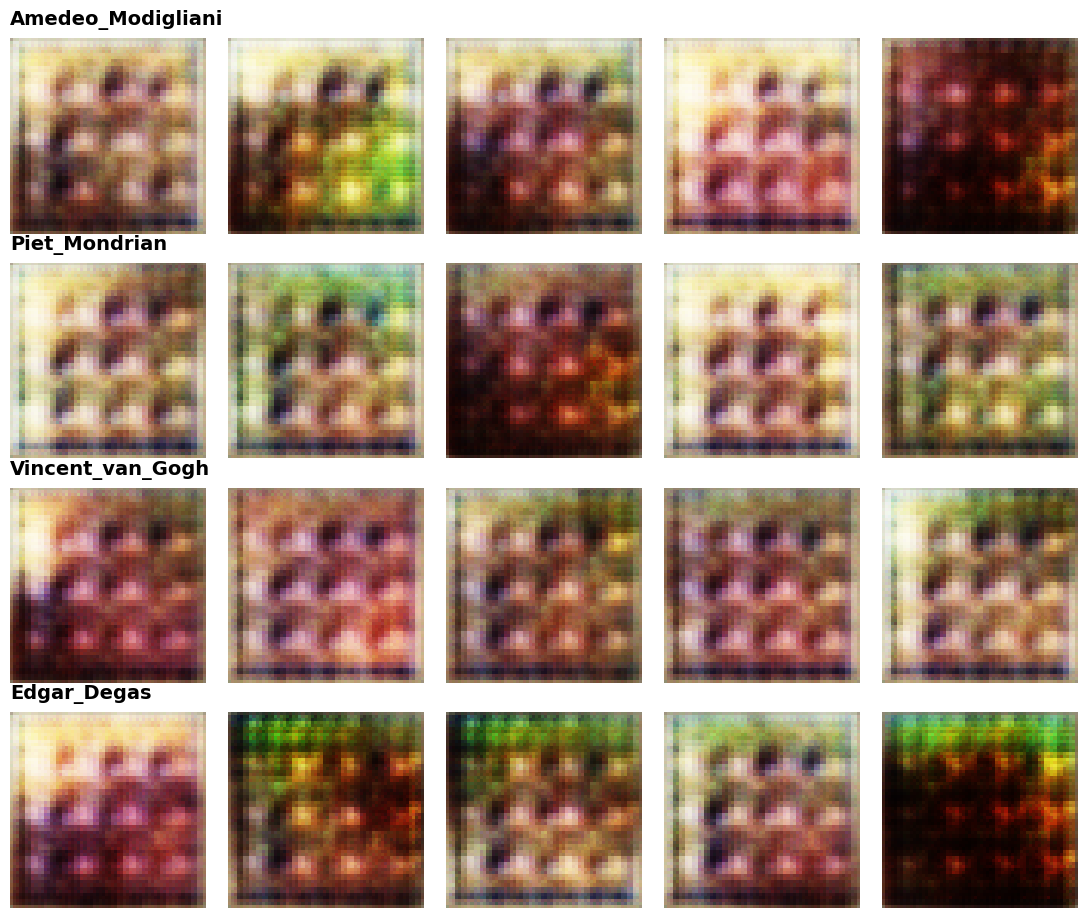


Epoch 12/1000
----------
Batch 1/29: Generator Loss: 0.7768, Discriminator Loss: 0.6948
----------
Epoch 12/1000: Generator Loss: 0.7001, Discriminator Loss: 0.7091, Time taken: 0:00:41.510485

Epoch 13/1000
----------
Batch 1/29: Generator Loss: 0.6972, Discriminator Loss: 0.7026
----------
Epoch 13/1000: Generator Loss: 0.6990, Discriminator Loss: 0.7053, Time taken: 0:00:41.235933

Epoch 14/1000
----------
Batch 1/29: Generator Loss: 0.7115, Discriminator Loss: 0.7008
----------
Epoch 14/1000: Generator Loss: 0.6954, Discriminator Loss: 0.7079, Time taken: 0:00:40.999306

Epoch 15/1000
----------
Batch 1/29: Generator Loss: 0.7378, Discriminator Loss: 0.7030
----------
Epoch 15/1000: Generator Loss: 0.7045, Discriminator Loss: 0.7092, Time taken: 0:00:41.048512

Epoch 16/1000
----------
Batch 1/29: Generator Loss: 0.7169, Discriminator Loss: 0.6958
----------
Epoch 16/1000: Generator Loss: 0.7034, Discriminator Loss: 0.7052, Time taken: 0:00:41.732166

Epoch 17/1000
----------
Batc

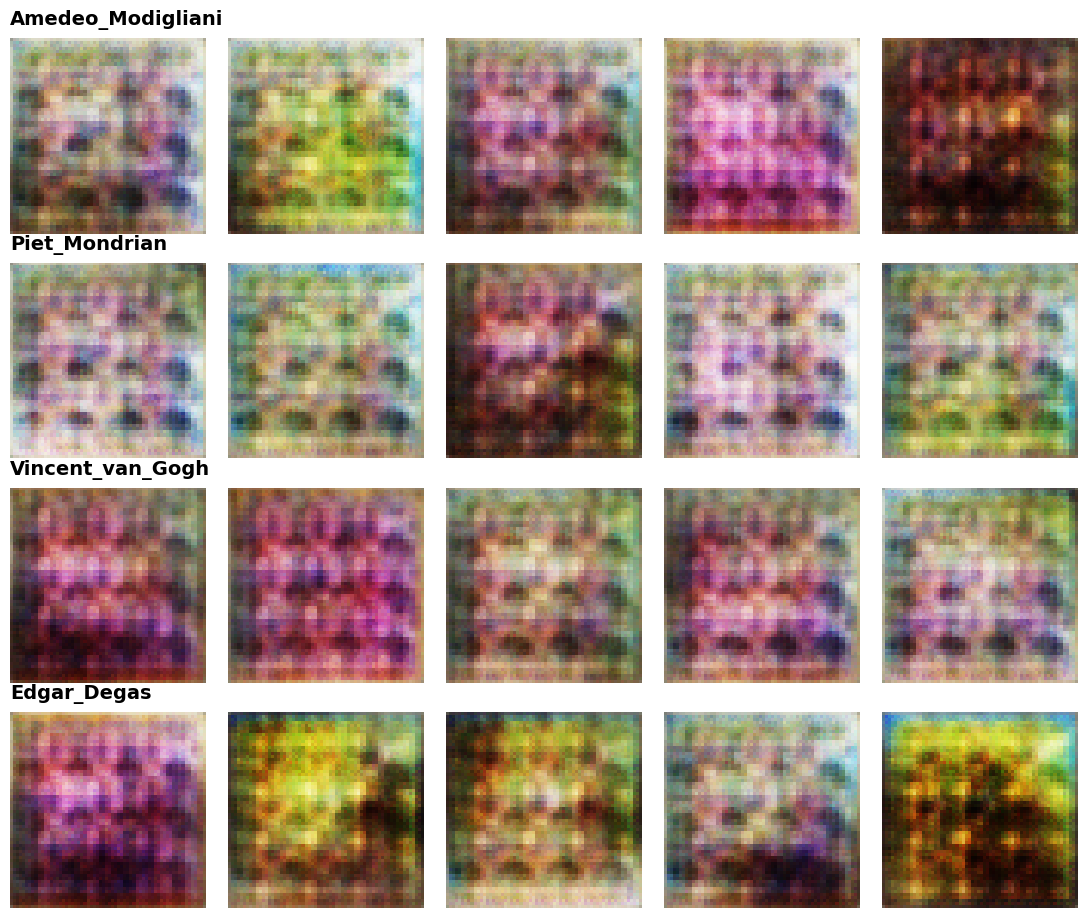


Epoch 22/1000
----------
Batch 1/29: Generator Loss: 0.6918, Discriminator Loss: 0.7050
----------
Epoch 22/1000: Generator Loss: 0.7014, Discriminator Loss: 0.7023, Time taken: 0:00:41.648758

Epoch 23/1000
----------
Batch 1/29: Generator Loss: 0.6946, Discriminator Loss: 0.6981
----------
Epoch 23/1000: Generator Loss: 0.6953, Discriminator Loss: 0.7000, Time taken: 0:00:42.086182

Epoch 24/1000
----------
Batch 1/29: Generator Loss: 0.6992, Discriminator Loss: 0.7001
----------
Epoch 24/1000: Generator Loss: 0.6936, Discriminator Loss: 0.7005, Time taken: 0:00:42.191214

Epoch 25/1000
----------
Batch 1/29: Generator Loss: 0.6987, Discriminator Loss: 0.6993
----------
Epoch 25/1000: Generator Loss: 0.6991, Discriminator Loss: 0.6991, Time taken: 0:00:42.516435

Epoch 26/1000
----------
Batch 1/29: Generator Loss: 0.7072, Discriminator Loss: 0.6950
----------
Epoch 26/1000: Generator Loss: 0.6964, Discriminator Loss: 0.6990, Time taken: 0:00:41.774449

Epoch 27/1000
----------
Batc

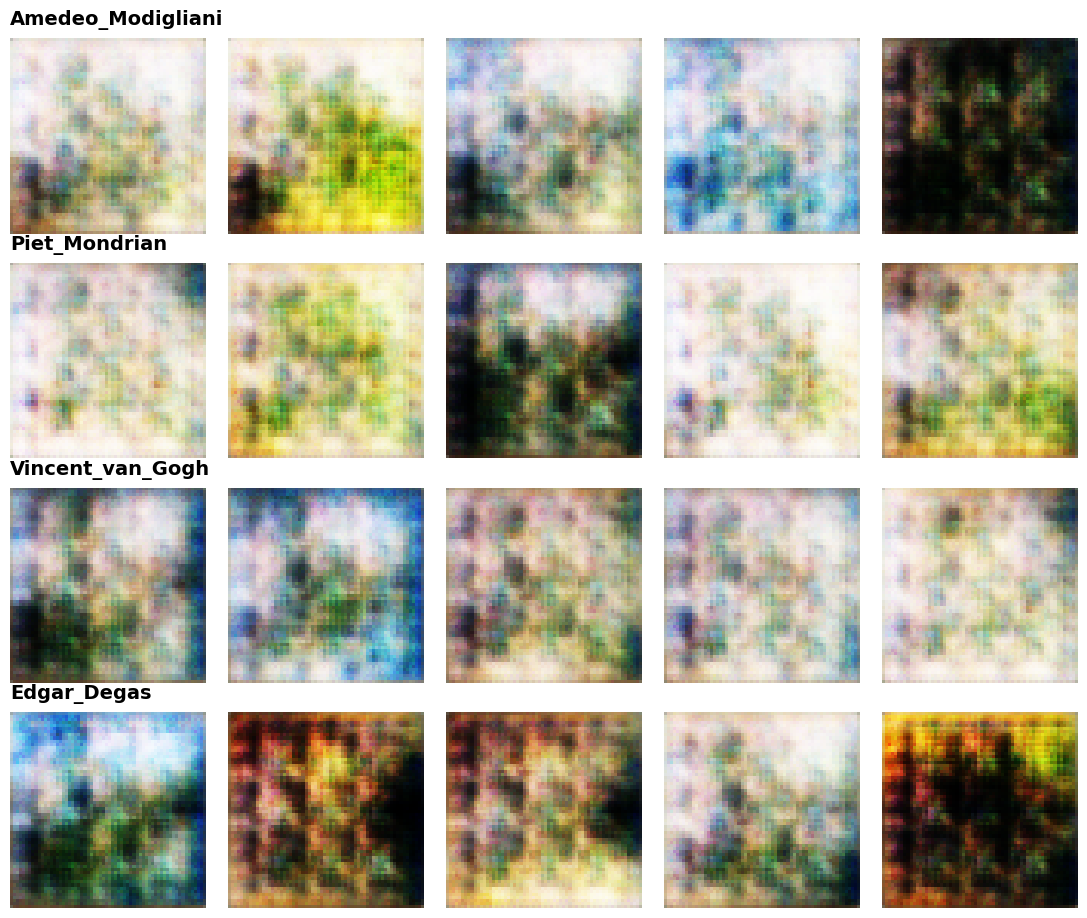


Epoch 32/1000
----------
Batch 1/29: Generator Loss: 0.7059, Discriminator Loss: 0.6949
----------
Epoch 32/1000: Generator Loss: 0.7005, Discriminator Loss: 0.7021, Time taken: 0:00:41.439438

Epoch 33/1000
----------
Batch 1/29: Generator Loss: 0.7067, Discriminator Loss: 0.6919
----------
Epoch 33/1000: Generator Loss: 0.6947, Discriminator Loss: 0.6998, Time taken: 0:00:42.395235

Epoch 34/1000
----------
Batch 1/29: Generator Loss: 0.6994, Discriminator Loss: 0.6988
----------
Epoch 34/1000: Generator Loss: 0.6906, Discriminator Loss: 0.6979, Time taken: 0:00:41.595367

Epoch 35/1000
----------
Batch 1/29: Generator Loss: 0.7034, Discriminator Loss: 0.6942
----------
Epoch 35/1000: Generator Loss: 0.6936, Discriminator Loss: 0.6995, Time taken: 0:00:41.476379

Epoch 36/1000
----------
Batch 1/29: Generator Loss: 0.6890, Discriminator Loss: 0.6992
----------
Epoch 36/1000: Generator Loss: 0.6946, Discriminator Loss: 0.6985, Time taken: 0:00:42.305344

Epoch 37/1000
----------
Batc

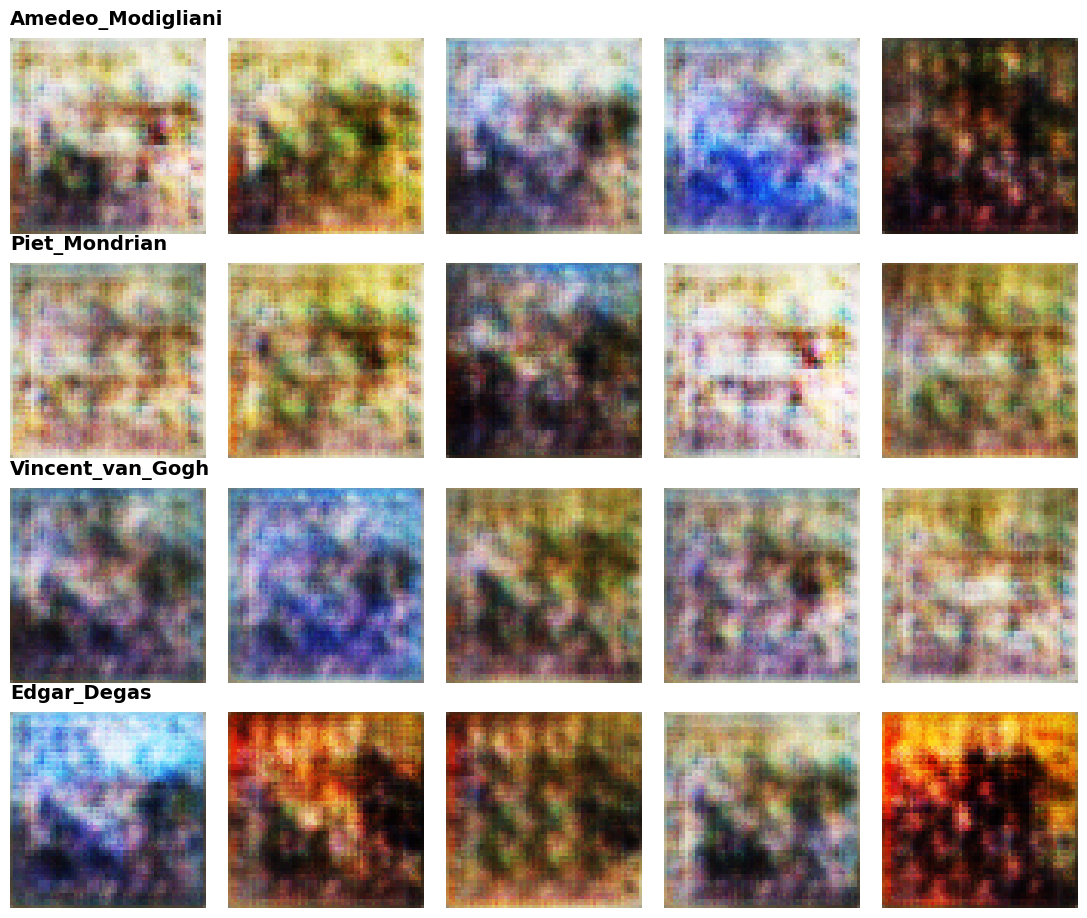


Epoch 42/1000
----------
Batch 1/29: Generator Loss: 0.7077, Discriminator Loss: 0.6921
----------
Epoch 42/1000: Generator Loss: 0.6949, Discriminator Loss: 0.6965, Time taken: 0:00:41.335257

Epoch 43/1000
----------
Batch 1/29: Generator Loss: 0.6952, Discriminator Loss: 0.6975
----------
Epoch 43/1000: Generator Loss: 0.6969, Discriminator Loss: 0.6976, Time taken: 0:00:41.442369

Epoch 44/1000
----------
Batch 1/29: Generator Loss: 0.6967, Discriminator Loss: 0.7007
----------
Epoch 44/1000: Generator Loss: 0.6944, Discriminator Loss: 0.6973, Time taken: 0:00:42.309605

Epoch 45/1000
----------
Batch 1/29: Generator Loss: 0.6947, Discriminator Loss: 0.6980
----------
Epoch 45/1000: Generator Loss: 0.6956, Discriminator Loss: 0.6974, Time taken: 0:00:41.688045

Epoch 46/1000
----------
Batch 1/29: Generator Loss: 0.6988, Discriminator Loss: 0.6954
----------
Epoch 46/1000: Generator Loss: 0.6915, Discriminator Loss: 0.6966, Time taken: 0:00:40.818114

Epoch 47/1000
----------
Batc

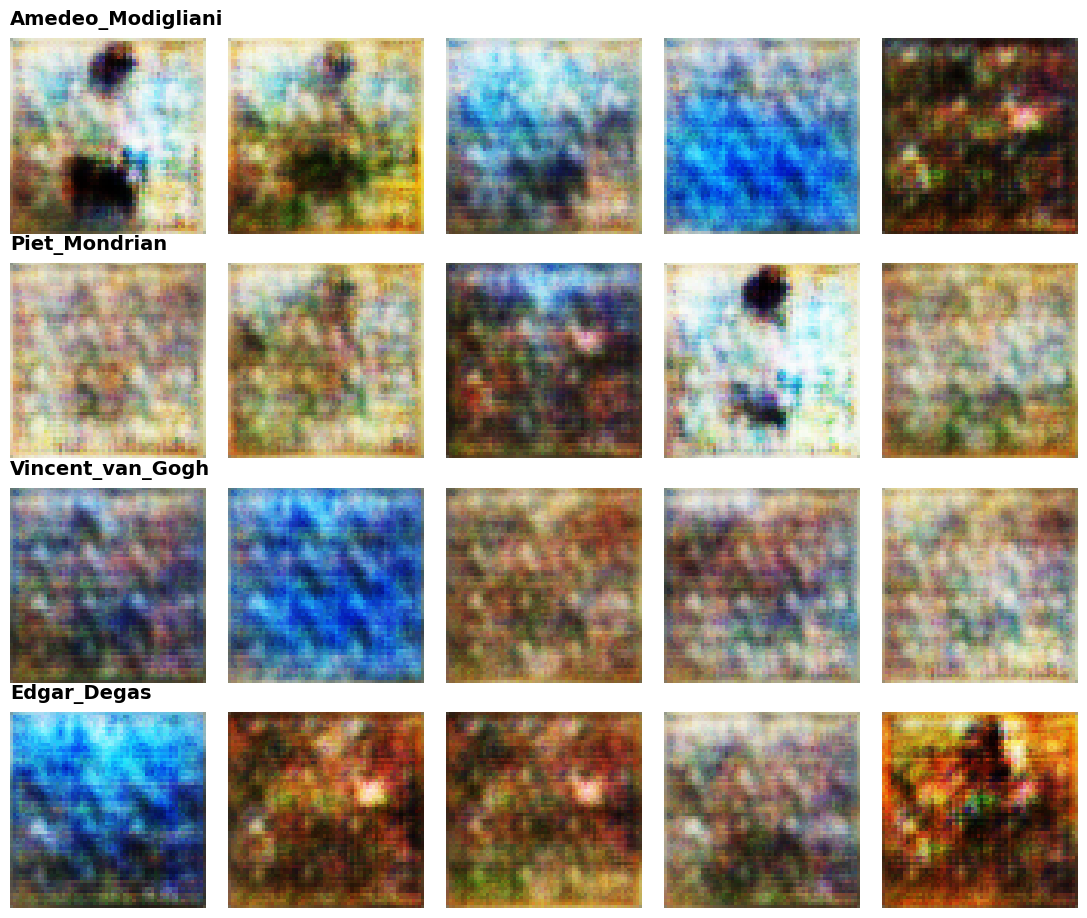


Epoch 52/1000
----------
Batch 1/29: Generator Loss: 0.6950, Discriminator Loss: 0.6965
----------
Epoch 52/1000: Generator Loss: 0.6951, Discriminator Loss: 0.6958, Time taken: 0:00:42.367862

Epoch 53/1000
----------
Batch 1/29: Generator Loss: 0.7010, Discriminator Loss: 0.6924
----------
Epoch 53/1000: Generator Loss: 0.6951, Discriminator Loss: 0.6960, Time taken: 0:00:42.722870

Epoch 54/1000
----------
Batch 1/29: Generator Loss: 0.7071, Discriminator Loss: 0.6902
----------
Epoch 54/1000: Generator Loss: 0.6963, Discriminator Loss: 0.6959, Time taken: 0:00:41.760153

Epoch 55/1000
----------
Batch 1/29: Generator Loss: 0.6933, Discriminator Loss: 0.6960
----------
Epoch 55/1000: Generator Loss: 0.7014, Discriminator Loss: 0.6960, Time taken: 0:00:41.703180

Epoch 56/1000
----------
Batch 1/29: Generator Loss: 0.6886, Discriminator Loss: 0.7026
----------
Epoch 56/1000: Generator Loss: 0.6930, Discriminator Loss: 0.6962, Time taken: 0:00:41.587690

Epoch 57/1000
----------
Batc

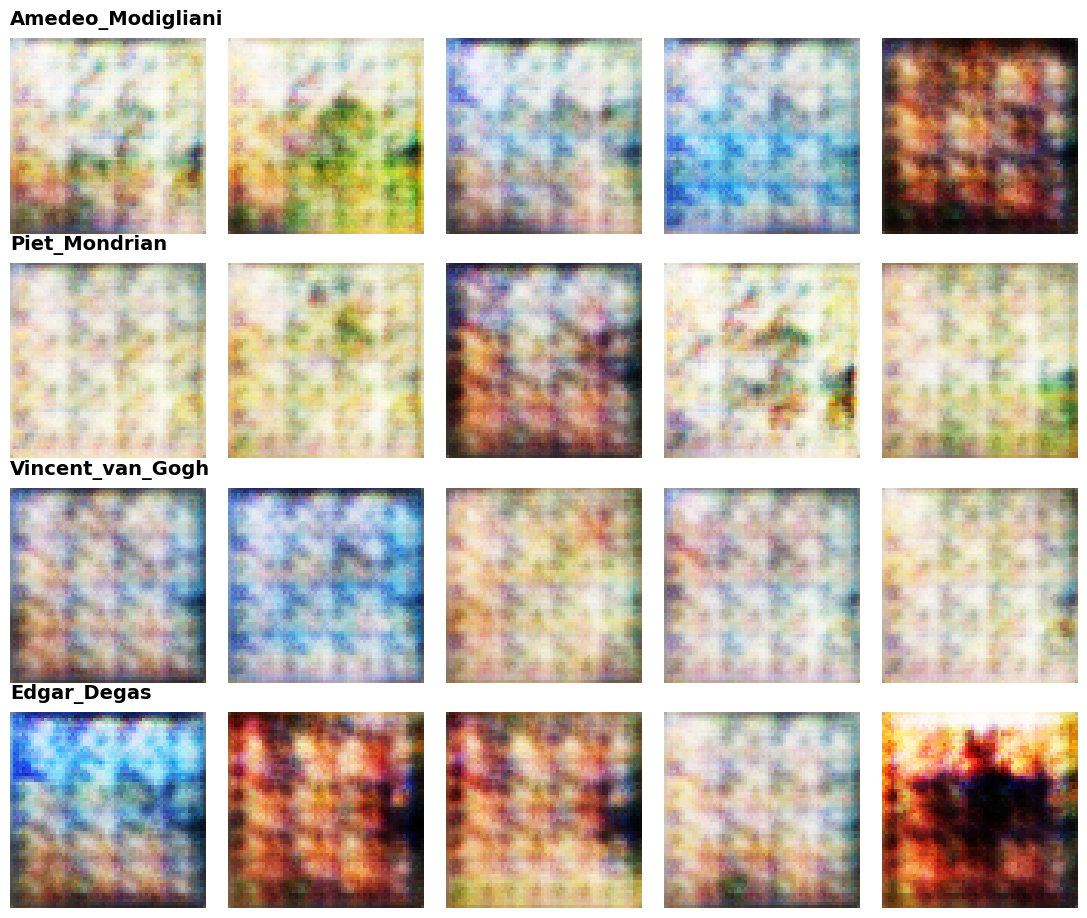


Epoch 62/1000
----------
Batch 1/29: Generator Loss: 0.6917, Discriminator Loss: 0.6968
----------
Epoch 62/1000: Generator Loss: 0.6965, Discriminator Loss: 0.6967, Time taken: 0:00:41.404130

Epoch 63/1000
----------
Batch 1/29: Generator Loss: 0.7001, Discriminator Loss: 0.6970
----------
Epoch 63/1000: Generator Loss: 0.6950, Discriminator Loss: 0.6957, Time taken: 0:00:41.328398

Epoch 64/1000
----------
Batch 1/29: Generator Loss: 0.7005, Discriminator Loss: 0.6936
----------
Epoch 64/1000: Generator Loss: 0.6935, Discriminator Loss: 0.6960, Time taken: 0:00:41.666026

Epoch 65/1000
----------
Batch 1/29: Generator Loss: 0.6983, Discriminator Loss: 0.6935
----------
Epoch 65/1000: Generator Loss: 0.6958, Discriminator Loss: 0.6961, Time taken: 0:00:40.960655

Epoch 66/1000
----------
Batch 1/29: Generator Loss: 0.6935, Discriminator Loss: 0.6922
----------
Epoch 66/1000: Generator Loss: 0.6930, Discriminator Loss: 0.6950, Time taken: 0:00:41.319024

Epoch 67/1000
----------
Batc

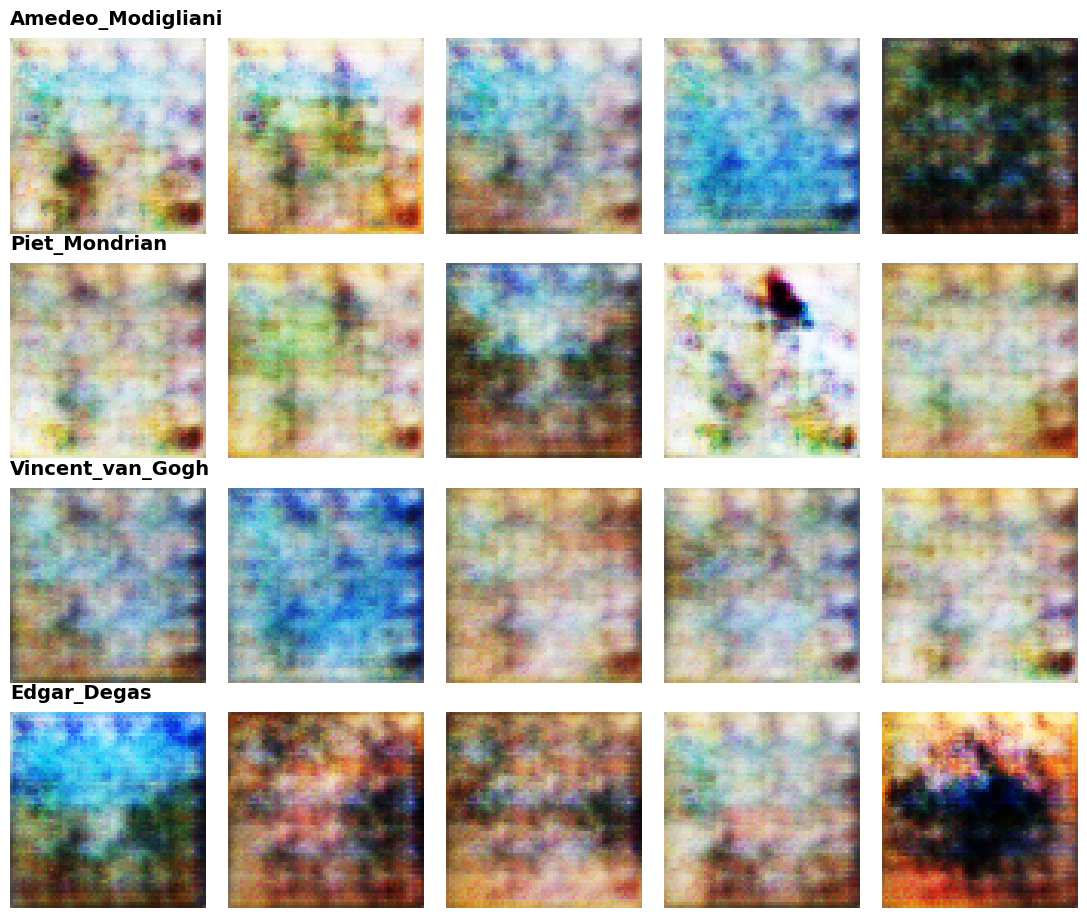


Epoch 72/1000
----------
Batch 1/29: Generator Loss: 0.6989, Discriminator Loss: 0.6955
----------
Epoch 72/1000: Generator Loss: 0.6960, Discriminator Loss: 0.6954, Time taken: 0:00:41.820538

Epoch 73/1000
----------
Batch 1/29: Generator Loss: 0.6917, Discriminator Loss: 0.6939
----------
Epoch 73/1000: Generator Loss: 0.6921, Discriminator Loss: 0.6954, Time taken: 0:00:42.025811

Epoch 74/1000
----------
Batch 1/29: Generator Loss: 0.6960, Discriminator Loss: 0.6952
----------
Epoch 74/1000: Generator Loss: 0.6937, Discriminator Loss: 0.6957, Time taken: 0:00:42.254095

Epoch 75/1000
----------
Batch 1/29: Generator Loss: 0.7054, Discriminator Loss: 0.6932
----------
Epoch 75/1000: Generator Loss: 0.6954, Discriminator Loss: 0.6950, Time taken: 0:00:42.351198

Epoch 76/1000
----------
Batch 1/29: Generator Loss: 0.6925, Discriminator Loss: 0.6939
----------
Epoch 76/1000: Generator Loss: 0.6936, Discriminator Loss: 0.6947, Time taken: 0:00:41.627663

Epoch 77/1000
----------
Batc

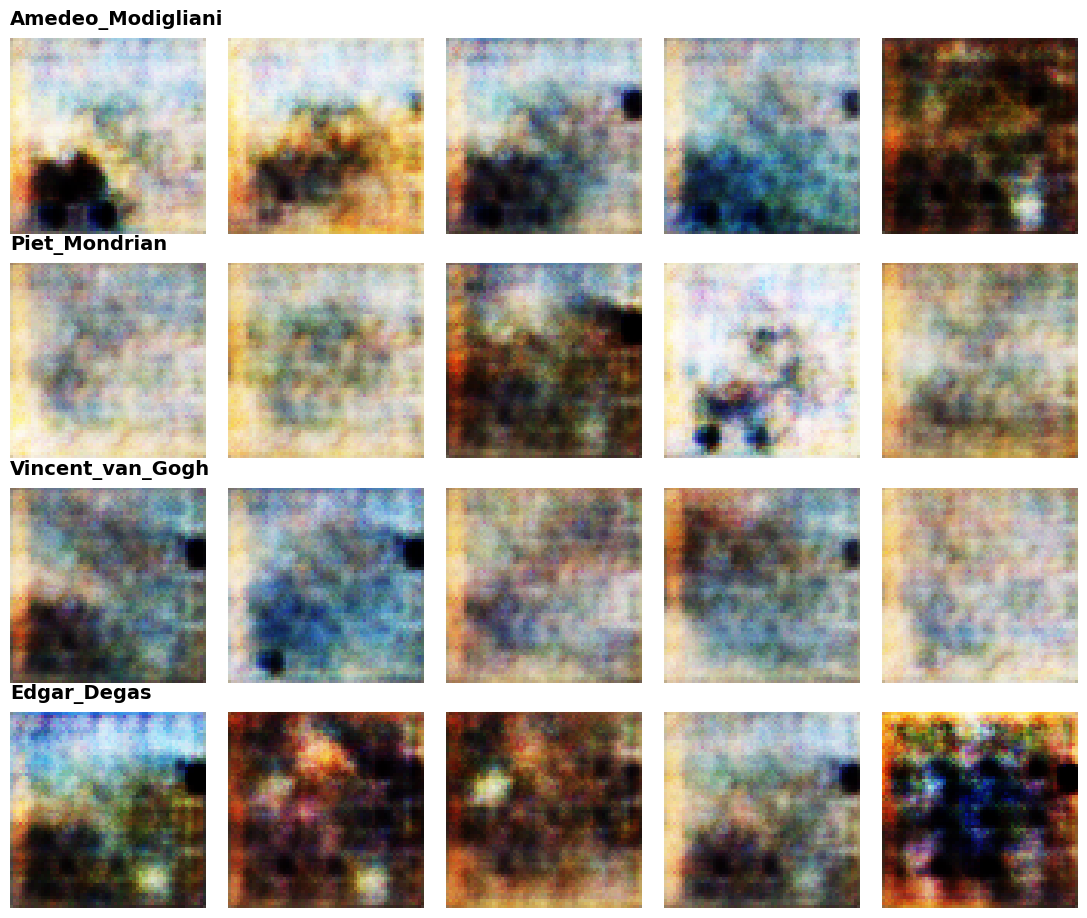


Epoch 82/1000
----------
Batch 1/29: Generator Loss: 0.7056, Discriminator Loss: 0.6938
----------
Epoch 82/1000: Generator Loss: 0.6966, Discriminator Loss: 0.6954, Time taken: 0:00:42.421679

Epoch 83/1000
----------
Batch 1/29: Generator Loss: 0.7015, Discriminator Loss: 0.6935
----------
Epoch 83/1000: Generator Loss: 0.6945, Discriminator Loss: 0.6949, Time taken: 0:00:41.980838

Epoch 84/1000
----------
Batch 1/29: Generator Loss: 0.6982, Discriminator Loss: 0.6955
----------
Epoch 84/1000: Generator Loss: 0.6964, Discriminator Loss: 0.6949, Time taken: 0:00:41.427487

Epoch 85/1000
----------
Batch 1/29: Generator Loss: 0.6975, Discriminator Loss: 0.6965
----------
Epoch 85/1000: Generator Loss: 0.6928, Discriminator Loss: 0.6961, Time taken: 0:00:41.639985

Epoch 86/1000
----------
Batch 1/29: Generator Loss: 0.6990, Discriminator Loss: 0.6927
----------
Epoch 86/1000: Generator Loss: 0.6949, Discriminator Loss: 0.6952, Time taken: 0:00:42.173027

Epoch 87/1000
----------
Batc

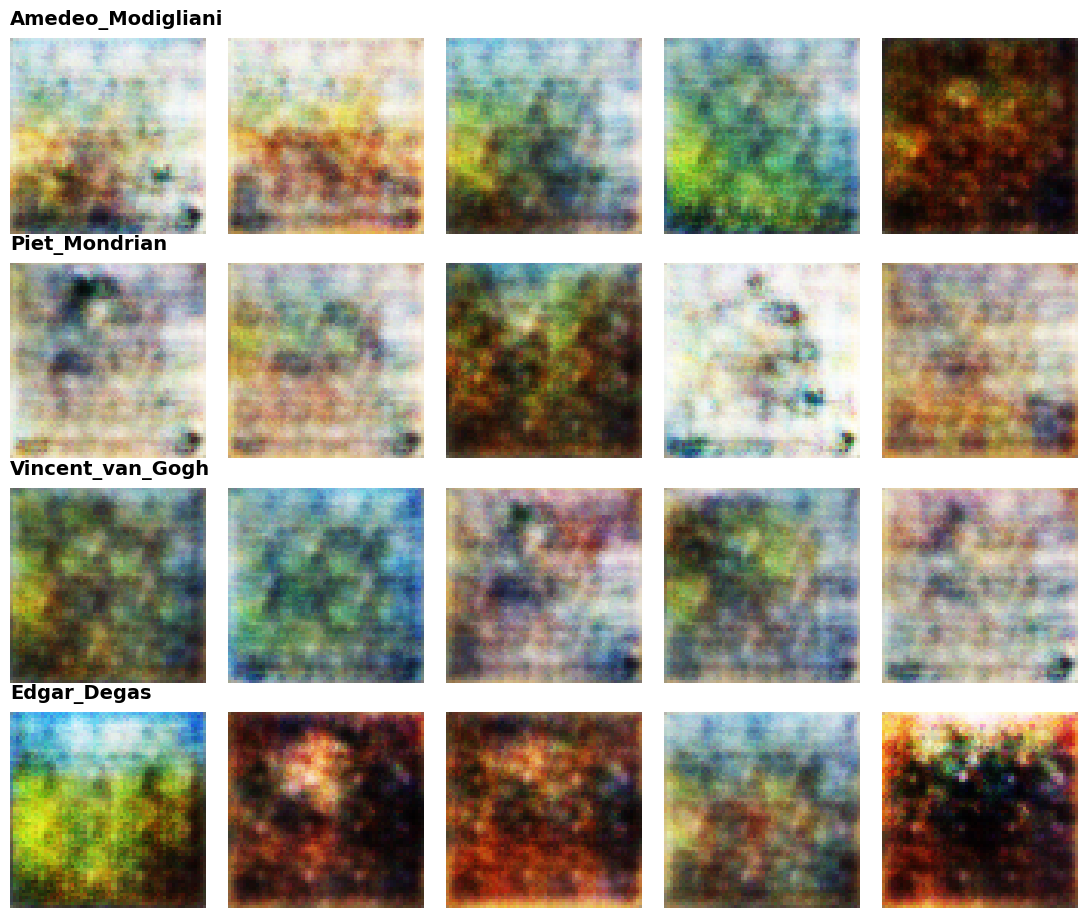


Epoch 92/1000
----------
Batch 1/29: Generator Loss: 0.6986, Discriminator Loss: 0.6921
----------
Epoch 92/1000: Generator Loss: 0.6959, Discriminator Loss: 0.6947, Time taken: 0:00:42.613317

Epoch 93/1000
----------
Batch 1/29: Generator Loss: 0.6990, Discriminator Loss: 0.6939
----------
Epoch 93/1000: Generator Loss: 0.6963, Discriminator Loss: 0.6942, Time taken: 0:00:42.161155

Epoch 94/1000
----------
Batch 1/29: Generator Loss: 0.7008, Discriminator Loss: 0.6948
----------
Epoch 94/1000: Generator Loss: 0.6933, Discriminator Loss: 0.6949, Time taken: 0:00:43.325107

Epoch 95/1000
----------
Batch 1/29: Generator Loss: 0.6931, Discriminator Loss: 0.6943
----------
Epoch 95/1000: Generator Loss: 0.6945, Discriminator Loss: 0.6950, Time taken: 0:00:42.751065

Epoch 96/1000
----------
Batch 1/29: Generator Loss: 0.7004, Discriminator Loss: 0.6982
----------
Epoch 96/1000: Generator Loss: 0.6952, Discriminator Loss: 0.6951, Time taken: 0:00:42.460545

Epoch 97/1000
----------
Batc

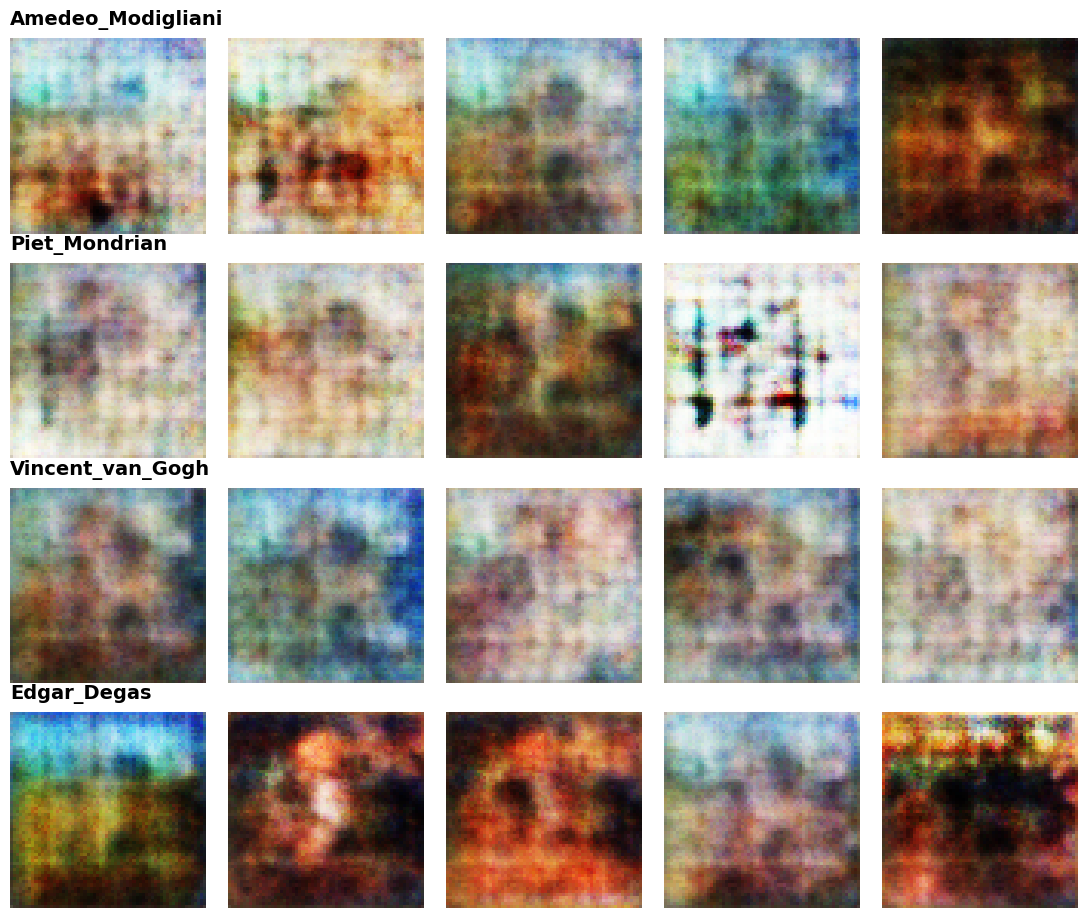


Epoch 102/1000
----------
Batch 1/29: Generator Loss: 0.6936, Discriminator Loss: 0.6929
----------
Epoch 102/1000: Generator Loss: 0.6950, Discriminator Loss: 0.6946, Time taken: 0:00:43.093623

Epoch 103/1000
----------
Batch 1/29: Generator Loss: 0.6959, Discriminator Loss: 0.6933
----------
Epoch 103/1000: Generator Loss: 0.6938, Discriminator Loss: 0.6949, Time taken: 0:00:43.869288

Epoch 104/1000
----------
Batch 1/29: Generator Loss: 0.6977, Discriminator Loss: 0.6938
----------
Epoch 104/1000: Generator Loss: 0.6938, Discriminator Loss: 0.6952, Time taken: 0:00:43.225842

Epoch 105/1000
----------
Batch 1/29: Generator Loss: 0.7039, Discriminator Loss: 0.6939
----------
Epoch 105/1000: Generator Loss: 0.6951, Discriminator Loss: 0.6947, Time taken: 0:00:43.640450

Epoch 106/1000
----------
Batch 1/29: Generator Loss: 0.7005, Discriminator Loss: 0.6935
----------
Epoch 106/1000: Generator Loss: 0.6947, Discriminator Loss: 0.6944, Time taken: 0:00:43.365352

Epoch 107/1000
----

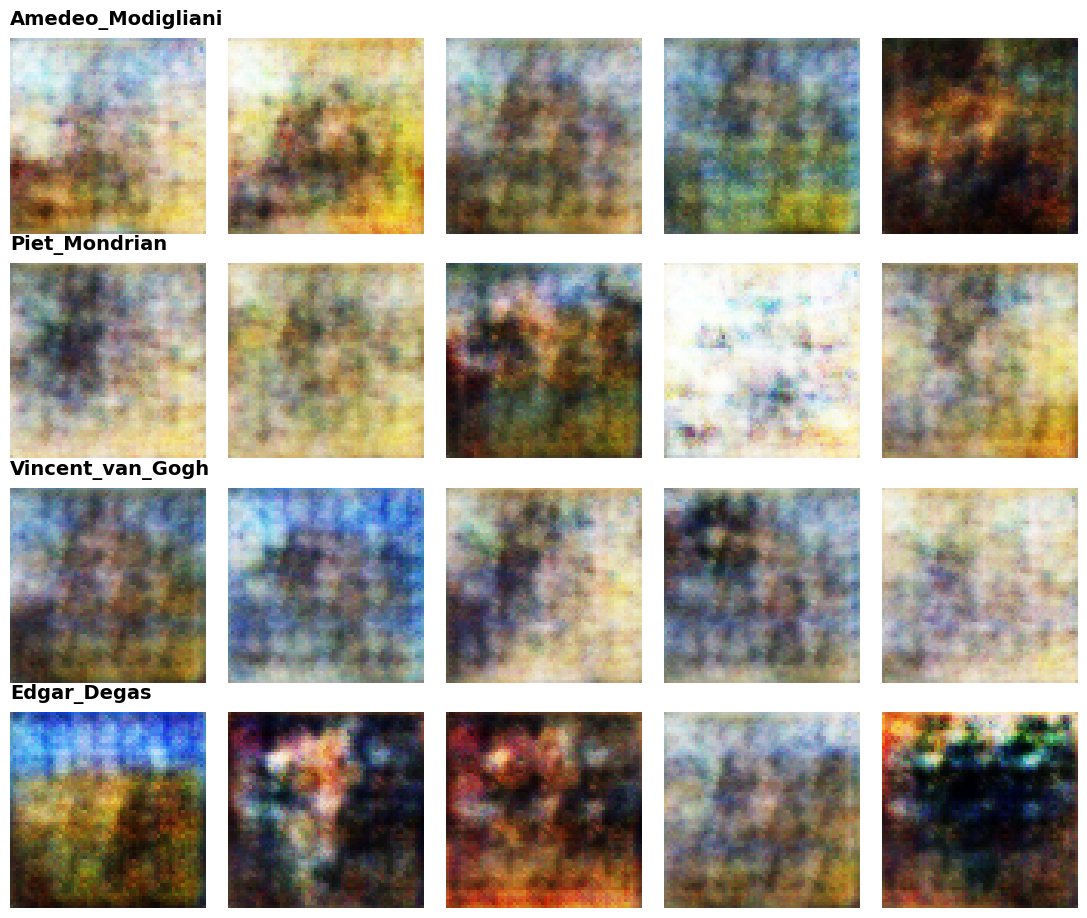


Epoch 112/1000
----------
Batch 1/29: Generator Loss: 0.6925, Discriminator Loss: 0.6955
----------
Epoch 112/1000: Generator Loss: 0.6931, Discriminator Loss: 0.6948, Time taken: 0:00:43.443641

Epoch 113/1000
----------
Batch 1/29: Generator Loss: 0.7033, Discriminator Loss: 0.6951
----------
Epoch 113/1000: Generator Loss: 0.6958, Discriminator Loss: 0.6944, Time taken: 0:00:43.026959

Epoch 114/1000
----------
Batch 1/29: Generator Loss: 0.6942, Discriminator Loss: 0.6923
----------
Epoch 114/1000: Generator Loss: 0.6934, Discriminator Loss: 0.6948, Time taken: 0:00:43.558836

Epoch 115/1000
----------
Batch 1/29: Generator Loss: 0.6959, Discriminator Loss: 0.6948
----------
Epoch 115/1000: Generator Loss: 0.6936, Discriminator Loss: 0.6944, Time taken: 0:00:43.272331

Epoch 116/1000
----------
Batch 1/29: Generator Loss: 0.6964, Discriminator Loss: 0.6940
----------
Epoch 116/1000: Generator Loss: 0.6956, Discriminator Loss: 0.6946, Time taken: 0:00:43.691999

Epoch 117/1000
----

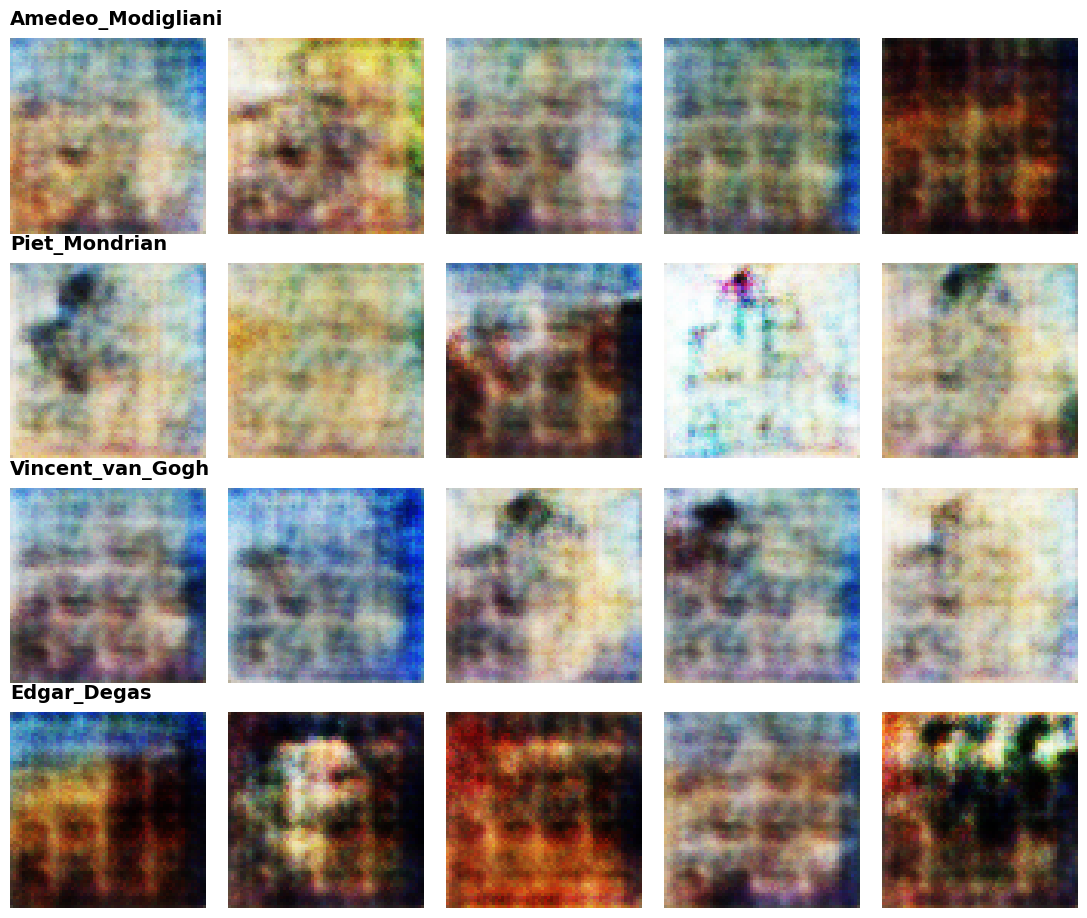


Epoch 122/1000
----------
Batch 1/29: Generator Loss: 0.6935, Discriminator Loss: 0.6946
----------
Epoch 122/1000: Generator Loss: 0.6958, Discriminator Loss: 0.6947, Time taken: 0:00:43.080531

Epoch 123/1000
----------
Batch 1/29: Generator Loss: 0.6940, Discriminator Loss: 0.6956
----------
Epoch 123/1000: Generator Loss: 0.6916, Discriminator Loss: 0.6946, Time taken: 0:00:43.065612

Epoch 124/1000
----------
Batch 1/29: Generator Loss: 0.7000, Discriminator Loss: 0.6943
----------
Epoch 124/1000: Generator Loss: 0.6956, Discriminator Loss: 0.6942, Time taken: 0:00:42.846796

Epoch 125/1000
----------
Batch 1/29: Generator Loss: 0.6944, Discriminator Loss: 0.6935
----------
Epoch 125/1000: Generator Loss: 0.6946, Discriminator Loss: 0.6945, Time taken: 0:00:43.418681

Epoch 126/1000
----------
Batch 1/29: Generator Loss: 0.6976, Discriminator Loss: 0.6937
----------
Epoch 126/1000: Generator Loss: 0.6926, Discriminator Loss: 0.6945, Time taken: 0:00:42.961033

Epoch 127/1000
----

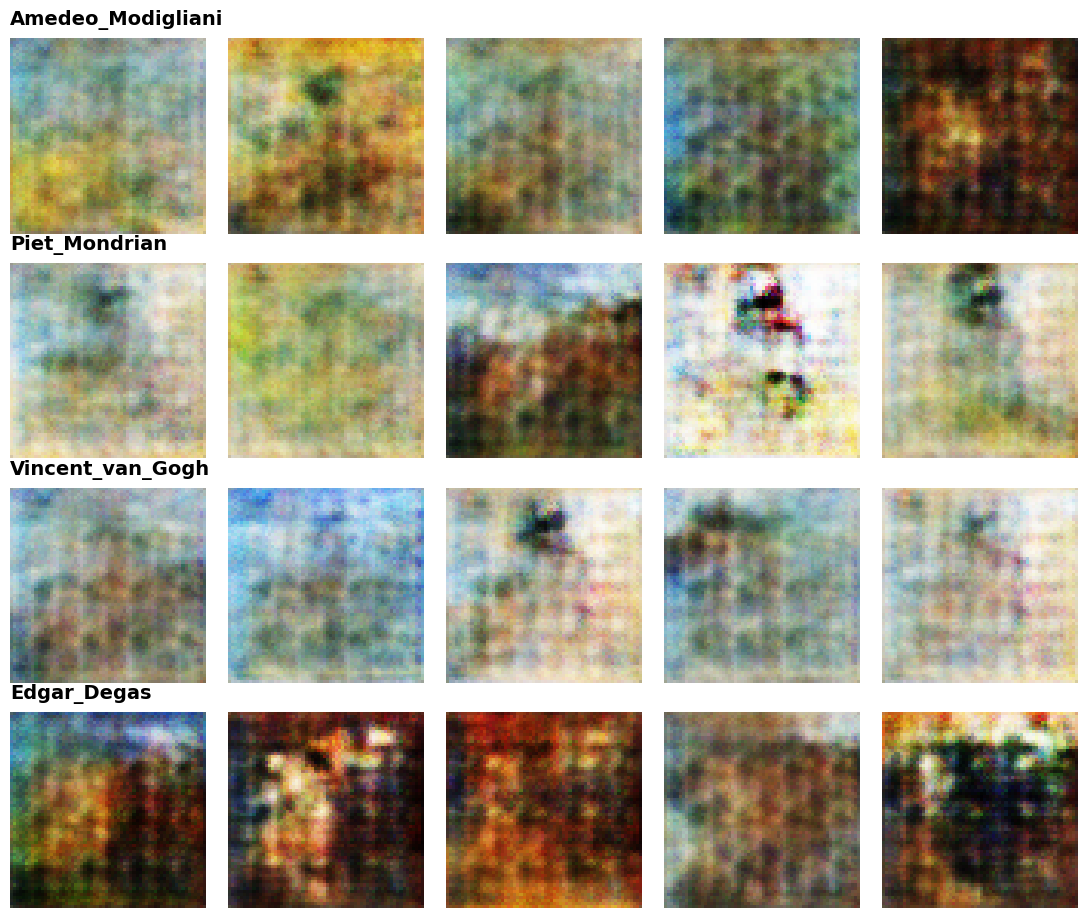


Epoch 132/1000
----------
Batch 1/29: Generator Loss: 0.6991, Discriminator Loss: 0.6942
----------
Epoch 132/1000: Generator Loss: 0.6938, Discriminator Loss: 0.6944, Time taken: 0:00:42.459163

Epoch 133/1000
----------
Batch 1/29: Generator Loss: 0.6996, Discriminator Loss: 0.6931
----------
Epoch 133/1000: Generator Loss: 0.6961, Discriminator Loss: 0.6944, Time taken: 0:00:42.508767

Epoch 134/1000
----------
Batch 1/29: Generator Loss: 0.6956, Discriminator Loss: 0.6952
----------
Epoch 134/1000: Generator Loss: 0.6928, Discriminator Loss: 0.6946, Time taken: 0:00:42.910323

Epoch 135/1000
----------
Batch 1/29: Generator Loss: 0.7016, Discriminator Loss: 0.6928
----------
Epoch 135/1000: Generator Loss: 0.6961, Discriminator Loss: 0.6943, Time taken: 0:00:42.486134

Epoch 136/1000
----------
Batch 1/29: Generator Loss: 0.6996, Discriminator Loss: 0.6920
----------
Epoch 136/1000: Generator Loss: 0.6932, Discriminator Loss: 0.6945, Time taken: 0:00:43.263227

Epoch 137/1000
----

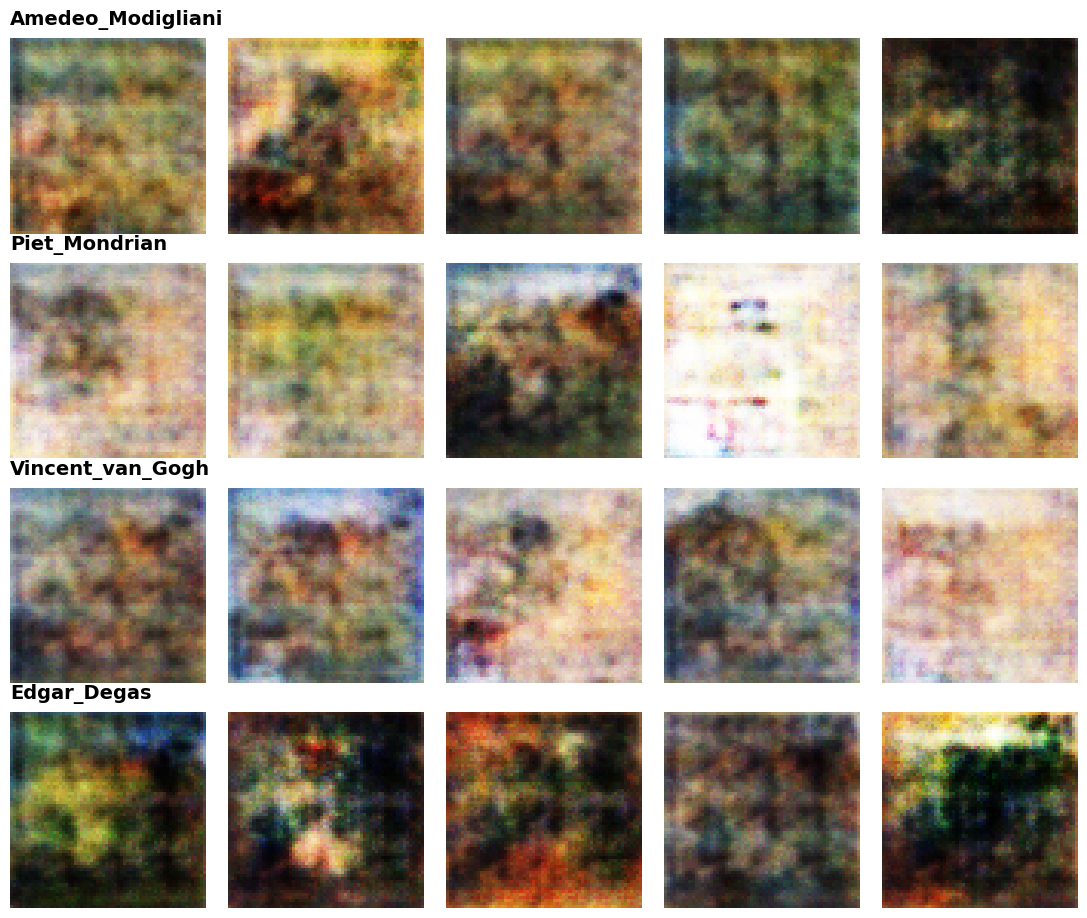


Epoch 142/1000
----------
Batch 1/29: Generator Loss: 0.6938, Discriminator Loss: 0.6934
----------
Epoch 142/1000: Generator Loss: 0.6938, Discriminator Loss: 0.6943, Time taken: 0:00:42.313734

Epoch 143/1000
----------
Batch 1/29: Generator Loss: 0.6959, Discriminator Loss: 0.6923
----------
Epoch 143/1000: Generator Loss: 0.6951, Discriminator Loss: 0.6941, Time taken: 0:00:42.904551

Epoch 144/1000
----------
Batch 1/29: Generator Loss: 0.6958, Discriminator Loss: 0.6942
----------
Epoch 144/1000: Generator Loss: 0.6938, Discriminator Loss: 0.6946, Time taken: 0:00:42.078820

Epoch 145/1000
----------
Batch 1/29: Generator Loss: 0.6971, Discriminator Loss: 0.6952
----------
Epoch 145/1000: Generator Loss: 0.6953, Discriminator Loss: 0.6942, Time taken: 0:00:41.686621

Epoch 146/1000
----------
Batch 1/29: Generator Loss: 0.7007, Discriminator Loss: 0.6921
----------
Epoch 146/1000: Generator Loss: 0.6961, Discriminator Loss: 0.6949, Time taken: 0:00:43.058929

Epoch 147/1000
----

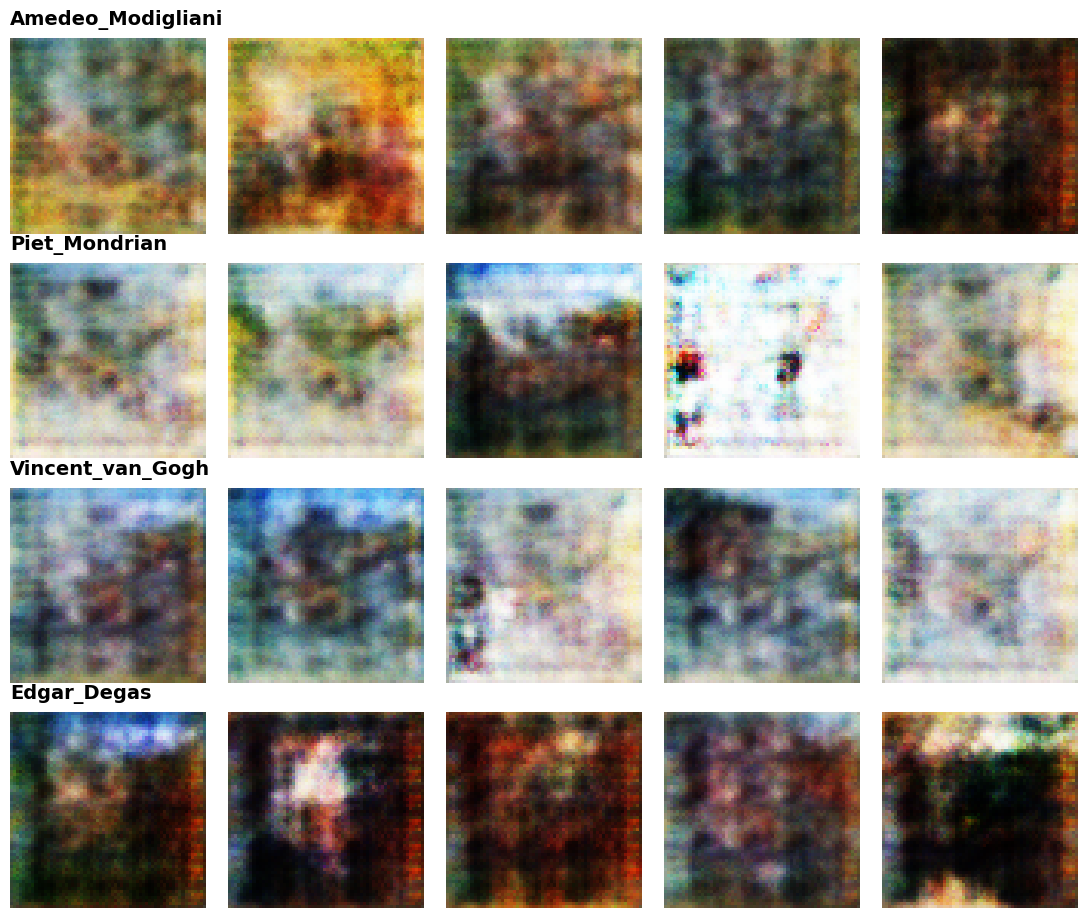


Epoch 152/1000
----------
Batch 1/29: Generator Loss: 0.6975, Discriminator Loss: 0.6940
----------
Epoch 152/1000: Generator Loss: 0.6944, Discriminator Loss: 0.6940, Time taken: 0:00:42.065459

Epoch 153/1000
----------
Batch 1/29: Generator Loss: 0.6990, Discriminator Loss: 0.6942
----------
Epoch 153/1000: Generator Loss: 0.6951, Discriminator Loss: 0.6938, Time taken: 0:00:42.451434

Epoch 154/1000
----------
Batch 1/29: Generator Loss: 0.6966, Discriminator Loss: 0.6935
----------
Epoch 154/1000: Generator Loss: 0.6945, Discriminator Loss: 0.6947, Time taken: 0:00:41.837925

Epoch 155/1000
----------
Batch 1/29: Generator Loss: 0.6976, Discriminator Loss: 0.6940
----------
Epoch 155/1000: Generator Loss: 0.6946, Discriminator Loss: 0.6940, Time taken: 0:00:41.481705

Epoch 156/1000
----------
Batch 1/29: Generator Loss: 0.7007, Discriminator Loss: 0.6930
----------
Epoch 156/1000: Generator Loss: 0.6957, Discriminator Loss: 0.6944, Time taken: 0:00:42.029675

Epoch 157/1000
----

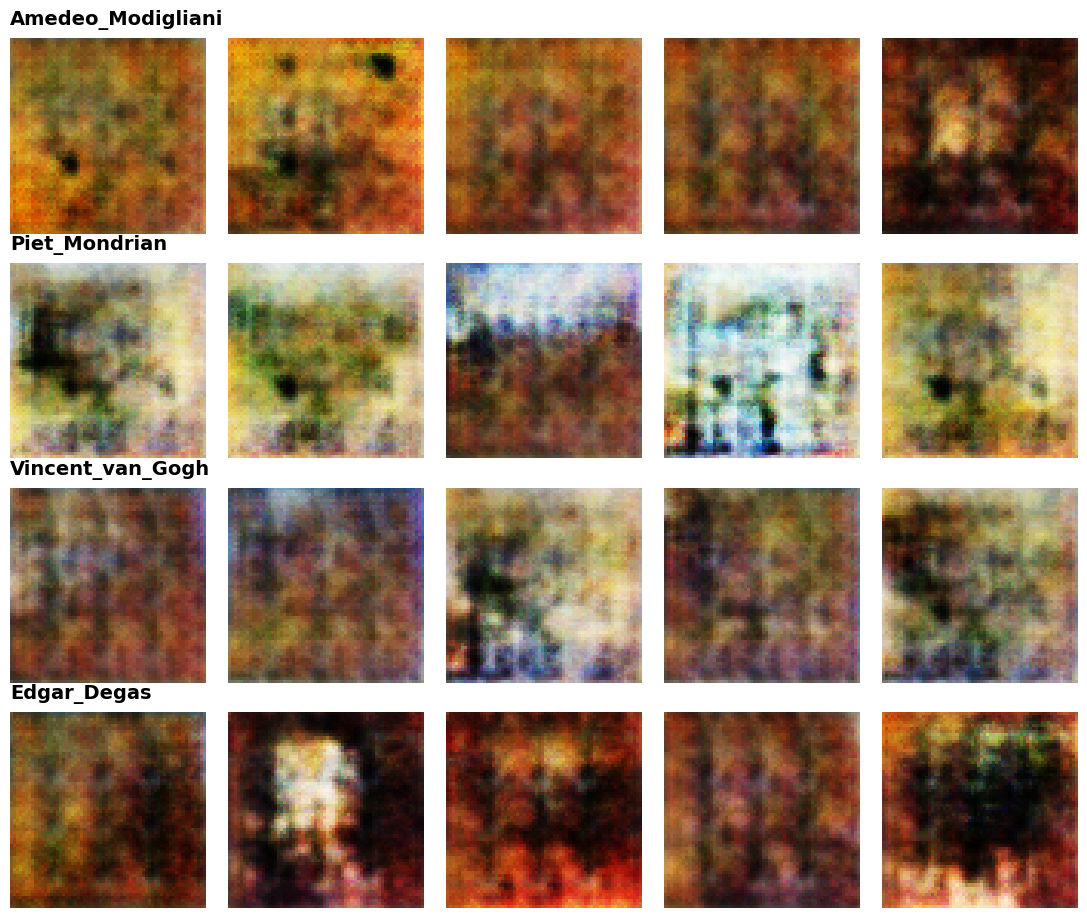


Epoch 162/1000
----------
Batch 1/29: Generator Loss: 0.6997, Discriminator Loss: 0.6939
----------
Epoch 162/1000: Generator Loss: 0.6934, Discriminator Loss: 0.6943, Time taken: 0:00:41.887268

Epoch 163/1000
----------
Batch 1/29: Generator Loss: 0.7003, Discriminator Loss: 0.6917
----------
Epoch 163/1000: Generator Loss: 0.6943, Discriminator Loss: 0.6941, Time taken: 0:00:41.799010

Epoch 164/1000
----------
Batch 1/29: Generator Loss: 0.7013, Discriminator Loss: 0.6938
----------
Epoch 164/1000: Generator Loss: 0.6947, Discriminator Loss: 0.6942, Time taken: 0:00:41.964248

Epoch 165/1000
----------
Batch 1/29: Generator Loss: 0.6995, Discriminator Loss: 0.6937
----------
Epoch 165/1000: Generator Loss: 0.6962, Discriminator Loss: 0.6937, Time taken: 0:00:41.684905

Epoch 166/1000
----------
Batch 1/29: Generator Loss: 0.6955, Discriminator Loss: 0.6938
----------
Epoch 166/1000: Generator Loss: 0.6961, Discriminator Loss: 0.6938, Time taken: 0:00:42.142431

Epoch 167/1000
----

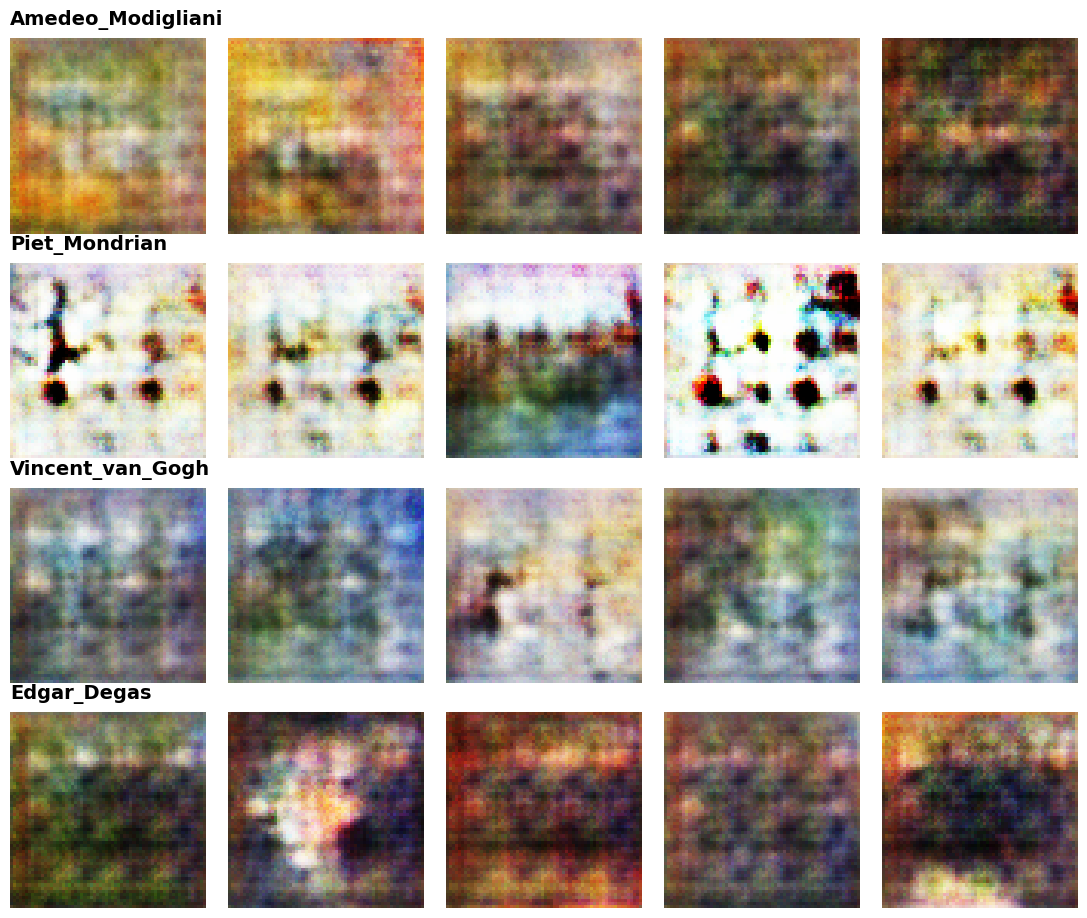


Epoch 172/1000
----------
Batch 1/29: Generator Loss: 0.6960, Discriminator Loss: 0.6939
----------
Epoch 172/1000: Generator Loss: 0.6956, Discriminator Loss: 0.6943, Time taken: 0:00:41.692686

Epoch 173/1000
----------
Batch 1/29: Generator Loss: 0.6938, Discriminator Loss: 0.6935
----------
Epoch 173/1000: Generator Loss: 0.6945, Discriminator Loss: 0.6935, Time taken: 0:00:41.658164

Epoch 174/1000
----------
Batch 1/29: Generator Loss: 0.6945, Discriminator Loss: 0.6928
----------
Epoch 174/1000: Generator Loss: 0.6953, Discriminator Loss: 0.6940, Time taken: 0:00:43.484798

Epoch 175/1000
----------
Batch 1/29: Generator Loss: 0.7018, Discriminator Loss: 0.6934
----------
Epoch 175/1000: Generator Loss: 0.6946, Discriminator Loss: 0.6940, Time taken: 0:00:42.630971

Epoch 176/1000
----------
Batch 1/29: Generator Loss: 0.7009, Discriminator Loss: 0.6946
----------
Epoch 176/1000: Generator Loss: 0.6944, Discriminator Loss: 0.6940, Time taken: 0:00:43.691668

Epoch 177/1000
----

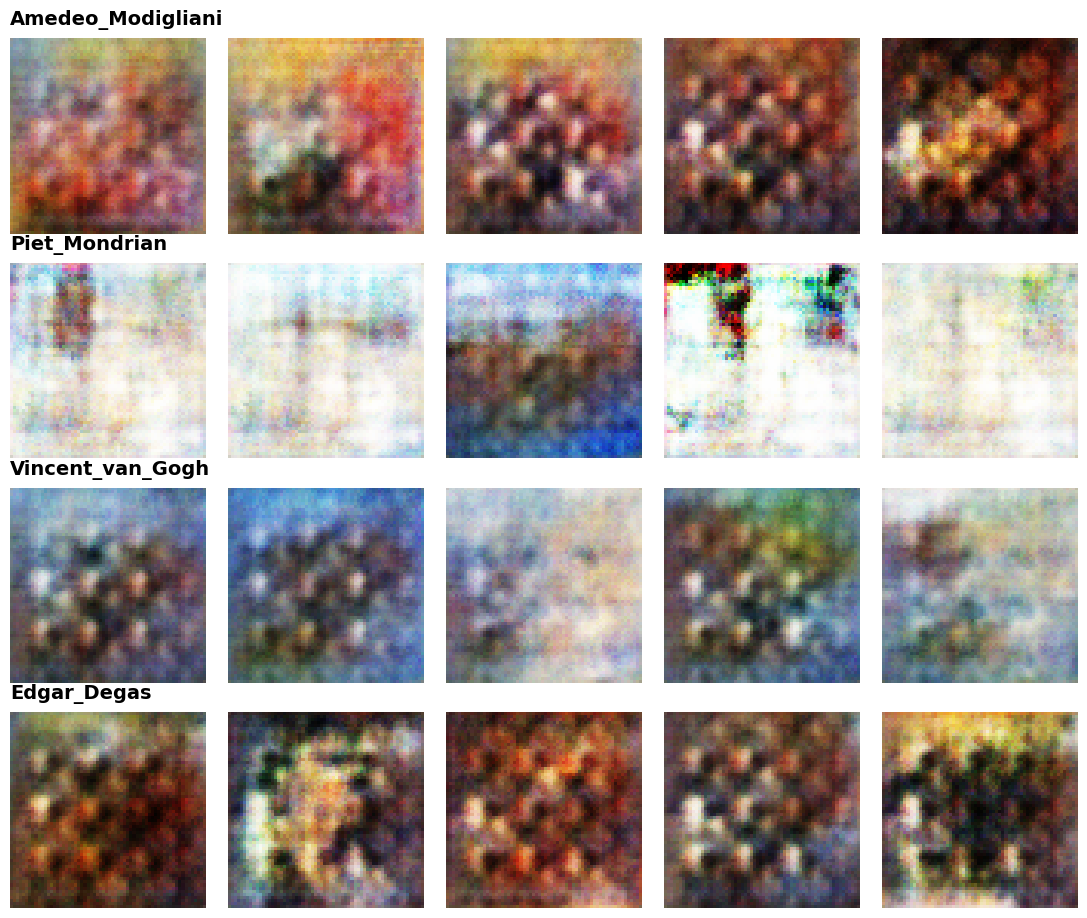


Epoch 182/1000
----------
Batch 1/29: Generator Loss: 0.6971, Discriminator Loss: 0.6937
----------
Epoch 182/1000: Generator Loss: 0.6952, Discriminator Loss: 0.6938, Time taken: 0:00:42.013086

Epoch 183/1000
----------
Batch 1/29: Generator Loss: 0.7006, Discriminator Loss: 0.6933


In [ ]:
num_batches = len(loader)
gen_losses_avg, disc_losses_avg = [], []
fix_latent_vector = torch.randn(size_latent_vector, latent_dim, 1, 1).to(device)
fix_class_labels = torch.tensor([0]*(size_latent_vector//nr_of_artists) +
 [1]*(size_latent_vector//nr_of_artists)+ [2]*(size_latent_vector//nr_of_artists)+
                                [3]*(size_latent_vector//nr_of_artists)).to(device)

for epoch in range(epochs):
    gen.train(), disc.train()

    print("\n" + f"Epoch {epoch + 1 }/{epochs}" + "\n" + "-" * 10)
    start_time = time.time()

    running_gen_loss, running_disc_loss = 0.0, 0.0
    for batch_idx, (real_images, class_labels) in enumerate(loader, start=0):
        real_images = real_images.to(device)
        class_labels = class_labels.to(device)

        noise = torch.randn(loader.batch_size,
                            latent_dim, 1, 1).to(device)

        fake_images = gen(noise, class_labels)

        # 1. Discriminator training: minimize - log(D(x)) - log(1 - D(G(z))).
        if batch_idx % 2 ==0:
          real_output = disc(real_images, class_labels).reshape(-1)
          fake_output = disc(fake_images, class_labels).reshape(-1)

          real_loss = loss(real_output, torch.ones_like(real_output))
          fake_loss = loss(fake_output, torch.zeros_like(fake_output))

          disc_loss = (real_loss + fake_loss) / 2

          optim_disc.zero_grad()
          disc_loss.backward(retain_graph=True)
          optim_disc.step()

        # 2. Generator training: minimize - log(D(G(z))).
        fake_output = disc(fake_images, class_labels).reshape(-1)
        gen_loss = loss(fake_output, torch.ones_like(fake_output))

        optim_gen.zero_grad()
        gen_loss.backward()
        optim_gen.step()

        if batch_idx % 100 == 0:
            print(f"Batch {batch_idx + 1}/{num_batches}: "
                  f"Generator Loss: {gen_loss.item():.4f}, "
                  f"Discriminator Loss: {disc_loss.item():.4f}")

        running_gen_loss += gen_loss.item()
        running_disc_loss += disc_loss.item()

    gen_losses_avg.append(running_gen_loss / num_batches)
    disc_losses_avg.append(running_disc_loss / num_batches)
    end_time = time.time()

    print("-" * 10 + "\n" + f"Epoch {epoch + 1}/{epochs}: "
          f"Generator Loss: {gen_losses_avg[-1]:.4f}, "
          f"Discriminator Loss: {disc_losses_avg[-1]:.4f}, "
          f"Time taken: {timedelta(seconds=end_time - start_time)}")


    if epoch % 10 == 0:
        # Sätt i eval-läge för generering
        gen.eval(), disc.eval()
        with torch.no_grad():
            fake_images = gen(fix_latent_vector, fix_class_labels).detach().cpu()

        # Konfiguration för snyggare grid: tätare och större bilder
        fig, axs = plt.subplots(4, 5, figsize=(12, 10), gridspec_kw={"wspace": 0.05, "hspace": 0.15})

        for i, ax in enumerate(axs.ravel()):
            # 1. Av-normalisera från [-1, 1] till [0, 1]
            img = fake_images[i] * 0.5 + 0.5

            # 2. Ändra från (C, H, W) till (H, W, C) för matplotlib
            img = img.permute(1, 2, 0).numpy()

            # 3. Visa bilden
            ax.imshow(np.clip(img, 0, 1))
            ax.axis("off")

            # Hitta vilken rad (0-3) och kolumn (0-4) vi är på
            row = i // 5
            col = i % 5

            # Sätt namn på konstnären över den FÖRSTA bilden på varje rad
            if col == 0 and row < len(selected_artists):
                ax.set_title(selected_artists[row], fontweight='bold', fontsize=14, loc='left', pad=10)

        # DESSA SKA VARA UTANFÖR FOR-LOOPEN (Samma indrag som "for i, ax...")
        plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)
        plt.show()
        plt.close(fig)

In [ ]:
plt.plot(gen_losses_avg, c='olive')
plt.plot(disc_losses_avg, c = 'peru')
plt.title('Generator and Discriminator loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Generator Loss', 'Discriminator Loss'])
plt.grid()